# HD figure regeneration

Runs every deck figure with `%matplotlib inline` so plots render in the notebook, and saves **300-DPI** PNGs to `derivatives/preproc/figures_HD/`. Each cell is self-contained — run top to bottom, or just the block you need.

In [1]:
%matplotlib inline
# HD figure regeneration -- renders every figure inline and saves 300-DPI PNGs to
# ~/Desktop/ds007615/ds007615/derivatives/preproc/figures_HD/
# Requires: pandas numpy matplotlib seaborn scikit-learn statsmodels mne specparam scipy
import os
os.makedirs("/Users/elizabethkaplan/Desktop/ds007615/ds007615/derivatives/preproc/figures_HD", exist_ok=True)
print("HD figures -> derivatives/preproc/figures_HD  (300 DPI)")

HD figures -> derivatives/preproc/figures_HD  (300 DPI)


## Figures 01–17 · sample, distributions, group comparisons, aperiodic overview, final model

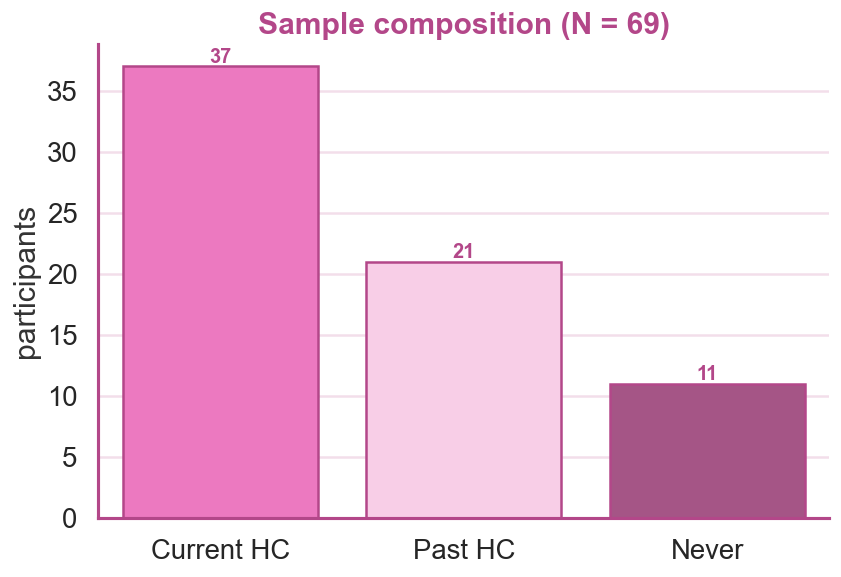

saved 01_sample_hc_groups.png


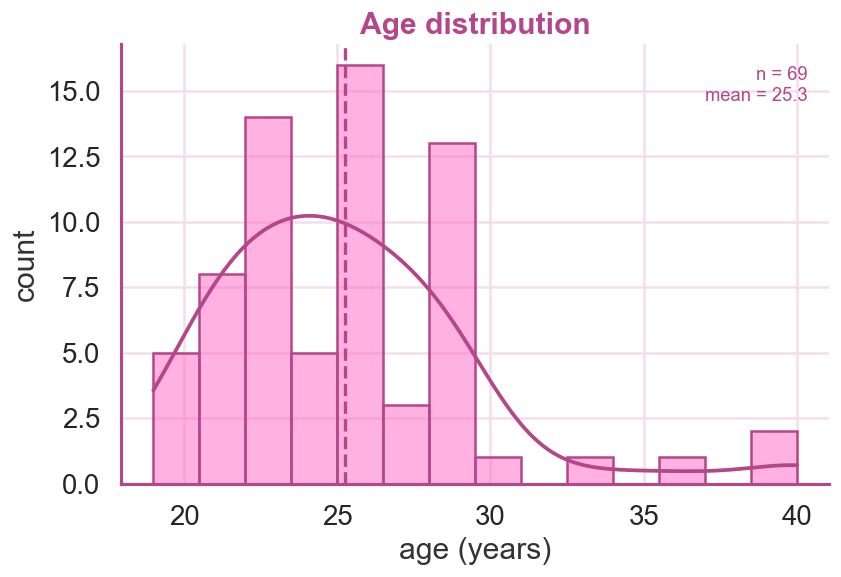

saved 02_age_dist.png


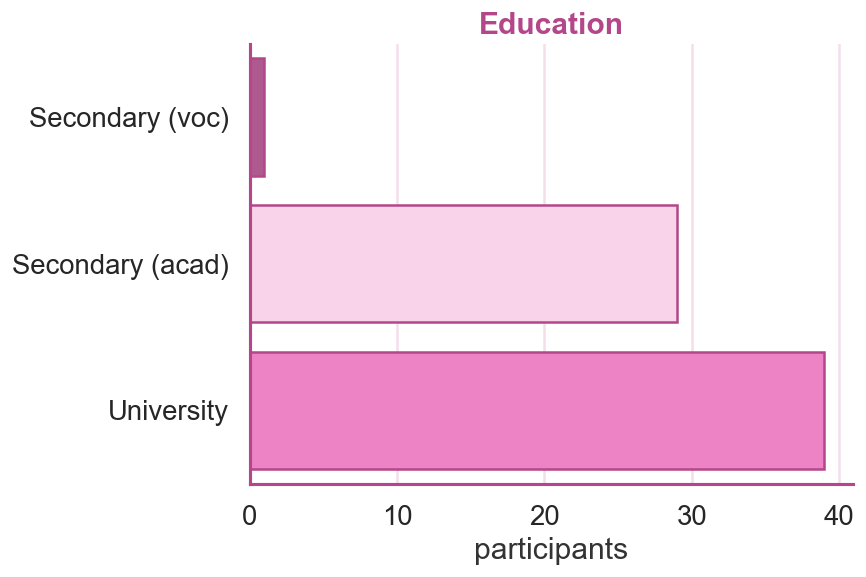

saved 03_education_dist.png


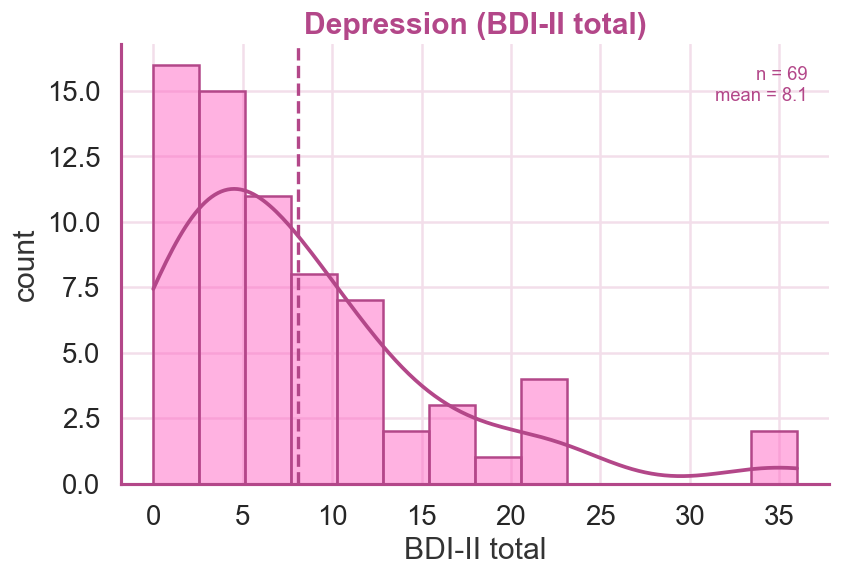

saved 04_bdi_dist.png


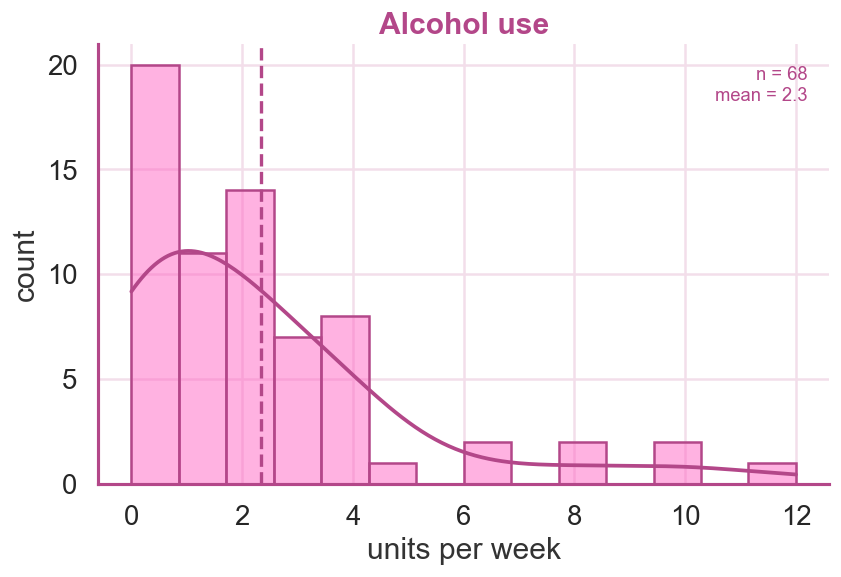

saved 05_alcohol_dist.png


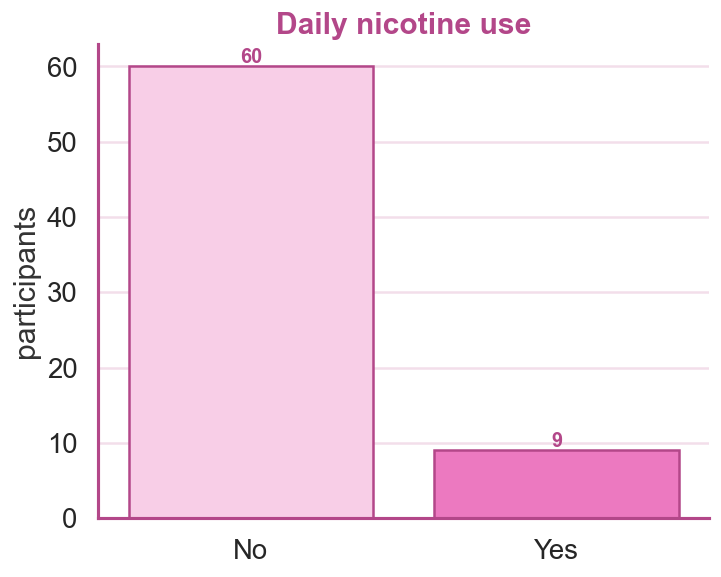

saved 06_nicotine_counts.png


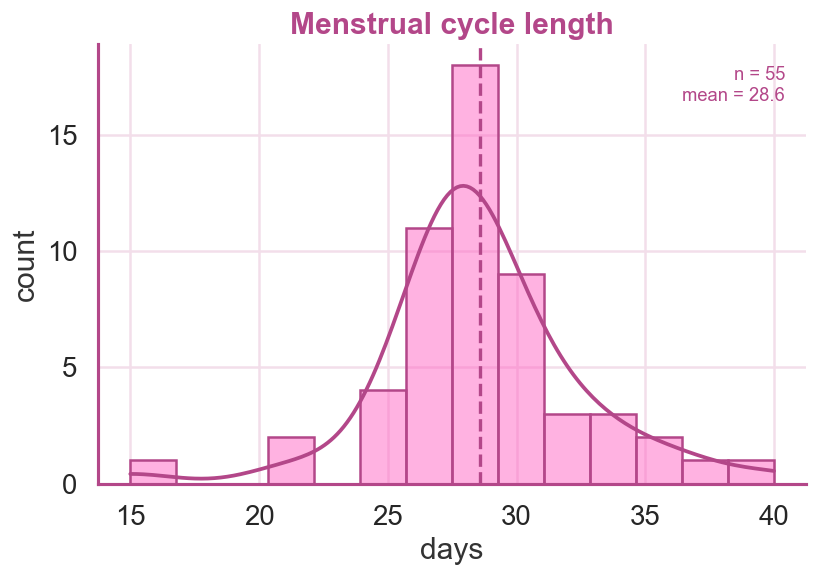

saved 07_cycle_length_dist.png


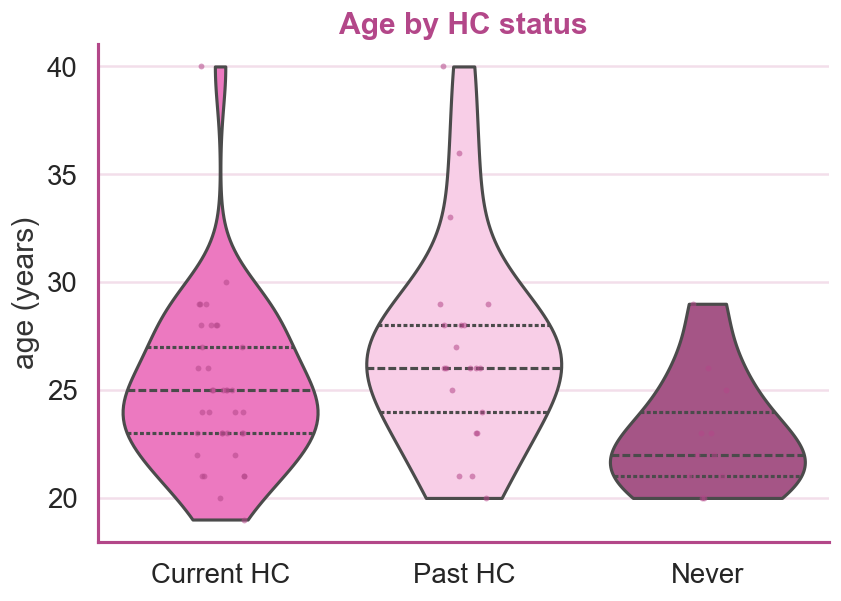

saved 08_age_by_group.png


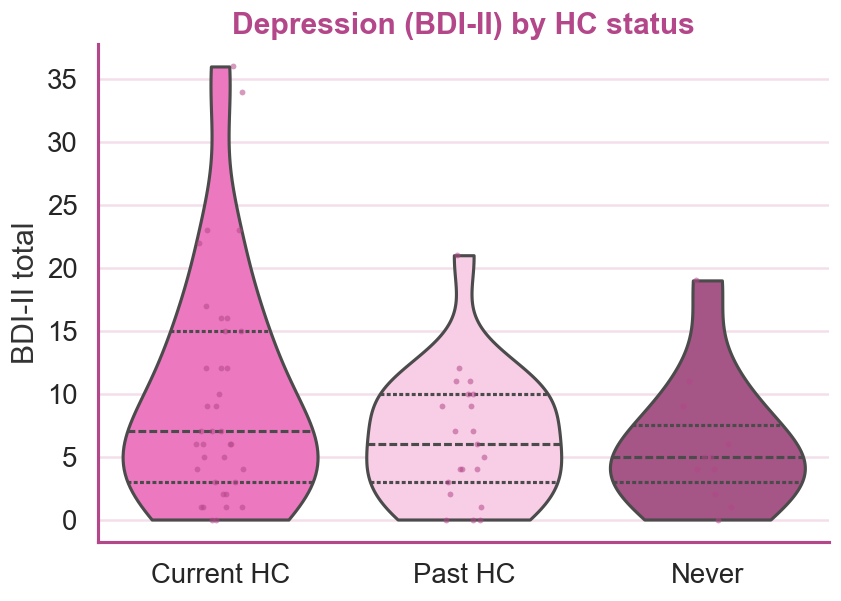

saved 09_bdi_by_group.png


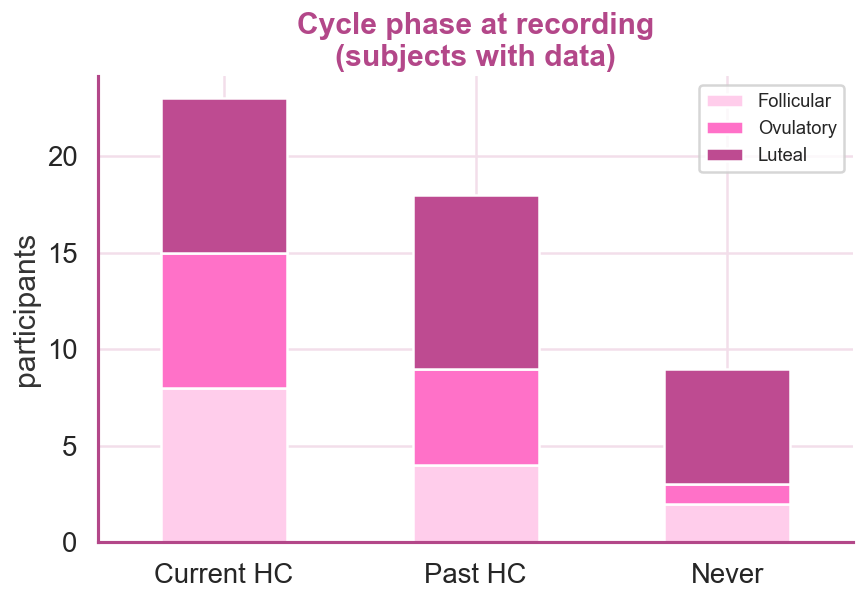

saved 10_cycle_phase_composition.png


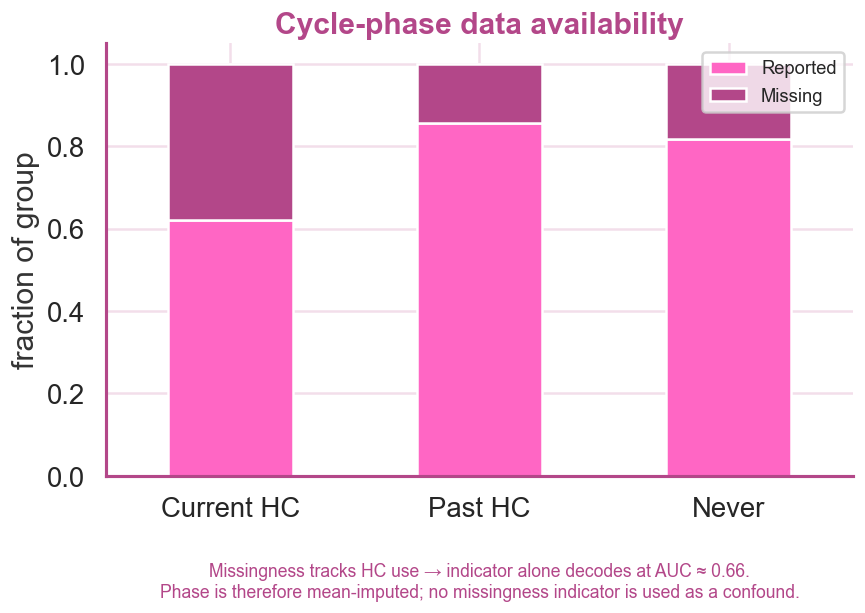

saved 11_cycle_phase_missingness.png


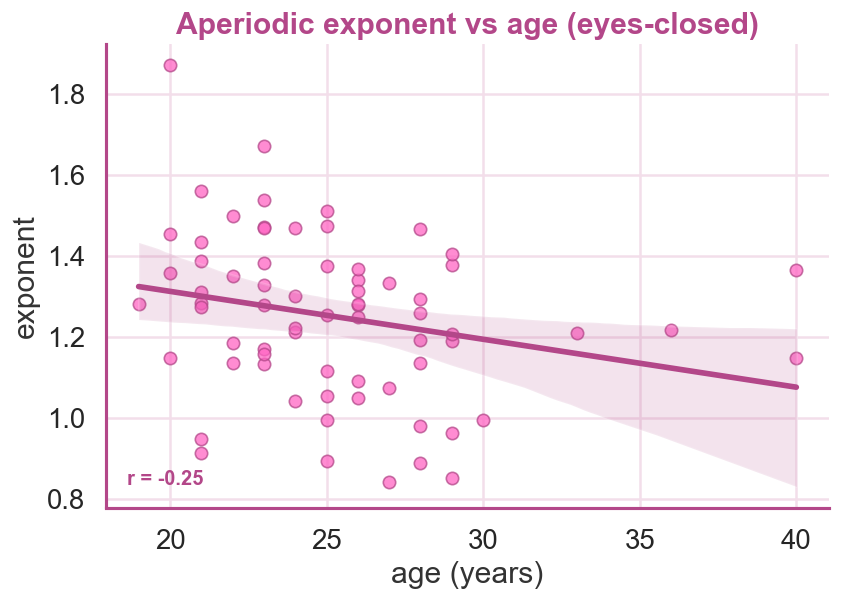

saved 13_exponent_vs_age.png


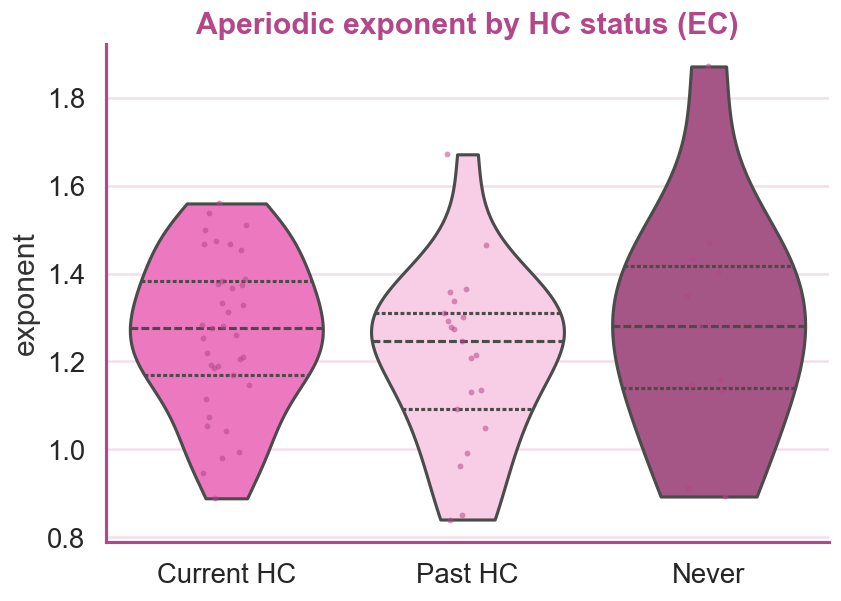

saved 14_exponent_by_group.png


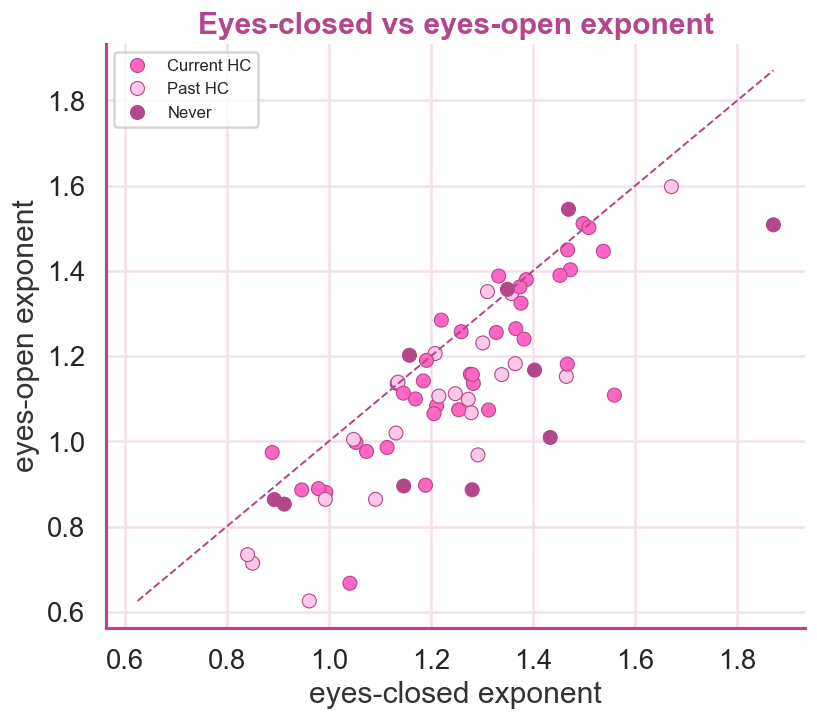

saved 15_ec_vs_eo_exponent.png


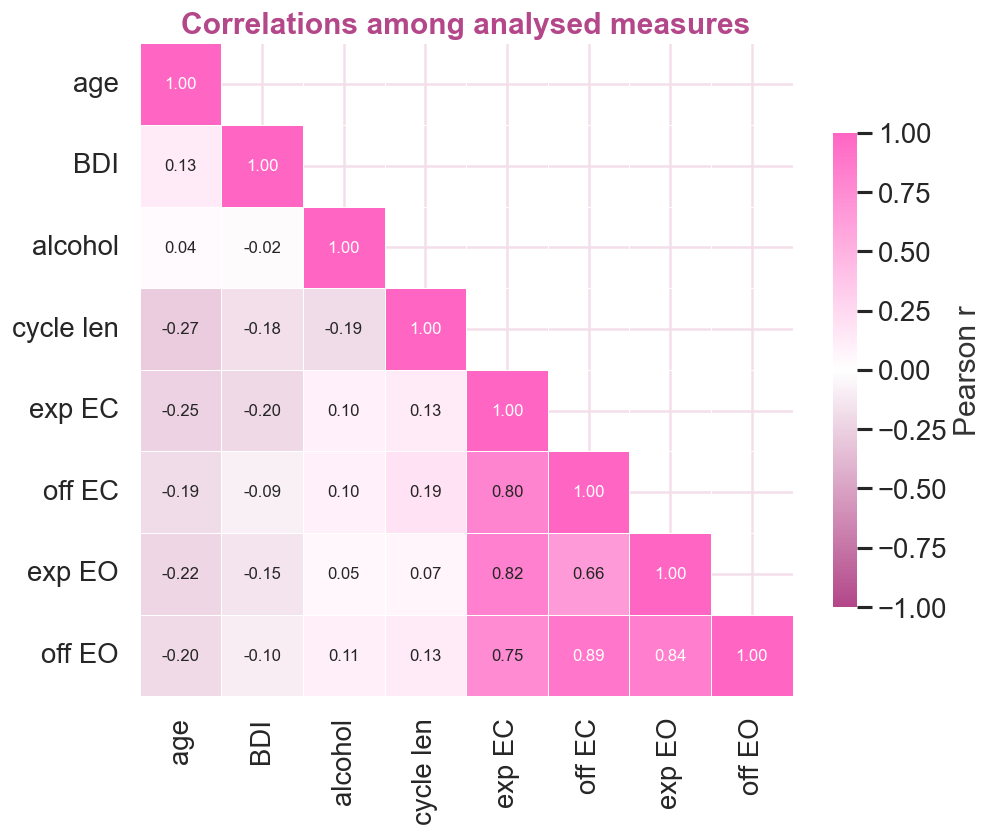

saved 16_correlation_heatmap.png


KeyboardInterrupt: 

In [2]:
"""
Presentation figures — aperiodic EEG / hormonal-contraceptive project.
ONE figure per file (single panel), sized for slides.

Colour palette (project brand):
    #FF66C4  bright pink   -> primary / Current-HC / positive
    #FFC7E9  light pink    -> secondary / Past-HC
    #B34789  deep magenta  -> accent / Never-user / negative
    #FFFFFF  white         -> background / diverging midpoint

Figures cover the variables analysed in the confound-controlled decode
(age, nicotine, alcohol, education, BDI, menstrual cycle phase), the aperiodic
parameters, and the FINAL model result.

Inputs
  <bids>/participants.tsv
  <phenotype>/bdi.tsv lifestyle.tsv hc_usage.tsv
  <bids>/derivatives/preproc/specparam/aperiodic_per_subject_channel.csv
Outputs (<bids>/derivatives/preproc/figures/)  -- each a standalone PNG
  01_sample_hc_groups.png        07_cycle_length_dist.png       13_exponent_vs_age.png
  02_age_dist.png                08_age_by_group.png            14_exponent_by_group.png
  03_education_dist.png          09_bdi_by_group.png            15_ec_vs_eo_exponent.png
  04_bdi_dist.png                10_cycle_phase_composition.png 16_correlation_heatmap.png
  05_alcohol_dist.png            11_cycle_phase_missingness.png 17_final_model.png
  06_nicotine_counts.png         12_confounds_correlation? (see 16)
  phenotype_merged.csv

Requires: pandas numpy matplotlib seaborn  (scikit-learn optional, for fig 17)
"""

import os
import numpy as np
import pandas as pd
import matplotlib
pass  # inline backend (set by %matplotlib inline)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ============================================================
# CONFIG + STYLE
# ============================================================
BIDS_ROOT     = "/Users/elizabethkaplan/Desktop/ds007615/ds007615"   # nested root (matches classification.ipynb)
DERIV_ROOT    = os.path.join(BIDS_ROOT, "derivatives", "preproc")
PHENOTYPE_DIR = "/Users/elizabethkaplan/Desktop/phenotype"
PARTICIPANTS  = os.path.join(BIDS_ROOT, "participants.tsv")
APERIODIC_CSV = os.path.join(DERIV_ROOT, "specparam", "aperiodic_per_subject_channel.csv")
OUT_DIR       = os.path.join(DERIV_ROOT, "figures_HD")
os.makedirs(OUT_DIR, exist_ok=True)

N_PERM_FINAL = 500   # permutation test for the final-model figure

# ---- brand palette ----
PINK  = "#FF66C4"; LIGHT = "#FFC7E9"; DARK = "#B34789"; WHITE = "#FFFFFF"
GROUP_PAL = {"Current HC": PINK, "Past HC": LIGHT, "Never": DARK}
CMAP_DIV = LinearSegmentedColormap.from_list("pink_div", [DARK, WHITE, PINK])
CMAP_SEQ = LinearSegmentedColormap.from_list("pink_seq", [WHITE, LIGHT, PINK, DARK])
def ramp(n): return [CMAP_SEQ(t) for t in np.linspace(0.30, 0.95, max(n, 1))]

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "axes.titleweight": "bold", "axes.titlecolor": DARK,
    "axes.edgecolor": DARK, "axes.labelcolor": "#333333",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#F3DEEA", "font.size": 13,
})

def save(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved", name)

def hist(col, label, name, unit=""):
    d = df[col].dropna()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    sns.histplot(d, bins=14, kde=True, color=PINK, edgecolor=DARK, ax=ax)
    if ax.lines: ax.lines[0].set_color(DARK)
    ax.axvline(d.mean(), color=DARK, ls="--", lw=2)
    ax.set_title(label); ax.set_xlabel(unit or label); ax.set_ylabel("count")
    ax.text(0.97, 0.95, f"n = {d.notna().sum()}\nmean = {d.mean():.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=11, color=DARK)
    save(fig, name)

def violin_by_group(col, label, name, unit=""):
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    sns.violinplot(data=df, x="HC group", y=col, order=present_groups, hue="HC group",
                   palette=GROUP_PAL, legend=False, inner="quartile", cut=0, ax=ax)
    sns.stripplot(data=df, x="HC group", y=col, order=present_groups, color=DARK,
                  size=3.5, alpha=.55, ax=ax)
    ax.set_title(label); ax.set_xlabel(""); ax.set_ylabel(unit or label)
    save(fig, name)


# ============================================================
# LOAD + MERGE + DECODE
# ============================================================
def sid(path):
    d = pd.read_csv(path, sep="\t", na_values="n/a")
    d["subject"] = d["participant_id"].str.replace("sub-", "", regex=False)
    return d.set_index("subject")

parts = sid(PARTICIPANTS)
bdi   = sid(os.path.join(PHENOTYPE_DIR, "bdi.tsv"))
life  = sid(os.path.join(PHENOTYPE_DIR, "lifestyle.tsv"))
hc    = sid(os.path.join(PHENOTYPE_DIR, "hc_usage.tsv"))

df = parts.join([bdi.drop(columns="participant_id"),
                 life.drop(columns="participant_id"),
                 hc.drop(columns="participant_id")], how="left")

df["HC group"] = df["group"].map({1: "Current HC", 2: "Past HC", 3: "Never"})
df["Education"] = df["edu"].map({1: "Primary", 2: "Secondary (voc)",
                                 3: "Secondary (acad)", 4: "University"})
df["Menstrual phase"] = df["mens_phase"].map({1: "Follicular", 2: "Ovulatory", 3: "Luteal"})
df["Daily nicotine"] = df["daily_nicotine"].map({1: "Yes", 2: "No"})

if os.path.exists(APERIODIC_CSV):
    ap = pd.read_csv(APERIODIC_CSV, dtype={"subject": str})
    for acq in ["ec", "eo"]:
        sub = ap[ap["acq"] == acq].groupby("subject")[["exponent", "offset"]].mean()
        df[f"exponent_{acq}"] = sub["exponent"]; df[f"offset_{acq}"] = sub["offset"]
    HAS_AP = df["exponent_ec"].notna().any()
else:
    HAS_AP = False

df.to_csv(os.path.join(OUT_DIR, "phenotype_merged.csv"))
GROUP_ORDER = ["Current HC", "Past HC", "Never"]
present_groups = [g for g in GROUP_ORDER if g in df["HC group"].values]
PHASE_ORDER = [p for p in ["Follicular", "Ovulatory", "Luteal"] if p in df["Menstrual phase"].values]


# ============================================================
# 01 — sample composition (HC groups)
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
sns.countplot(data=df, x="HC group", order=present_groups, hue="HC group",
              palette=GROUP_PAL, legend=False, ax=ax, edgecolor=DARK)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=12, color=DARK, fontweight="bold")
ax.set_title(f"Sample composition (N = {len(df)})"); ax.set_xlabel(""); ax.set_ylabel("participants")
save(fig, "01_sample_hc_groups.png")

# ============================================================
# 02–07 — distributions of variables we analysed
# ============================================================
hist("age", "Age distribution", "02_age_dist.png", "age (years)")

fig, ax = plt.subplots(figsize=(7.4, 5.0))
eo = [e for e in ["Primary", "Secondary (voc)", "Secondary (acad)", "University"]
      if e in df["Education"].values]
sns.countplot(data=df, y="Education", order=eo, hue="Education",
              palette=ramp(len(eo)), legend=False, ax=ax, edgecolor=DARK)
ax.set_title("Education"); ax.set_xlabel("participants"); ax.set_ylabel("")
save(fig, "03_education_dist.png")

hist("bdi_total", "Depression (BDI-II total)", "04_bdi_dist.png", "BDI-II total")
hist("alcohol_units", "Alcohol use", "05_alcohol_dist.png", "units per week")

fig, ax = plt.subplots(figsize=(6.2, 5.0))
d = df["Daily nicotine"].dropna()
sns.countplot(x=d, order=["No", "Yes"], hue=d, palette={"No": LIGHT, "Yes": PINK},
              legend=False, ax=ax, edgecolor=DARK)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=12, color=DARK, fontweight="bold")
ax.set_title("Daily nicotine use"); ax.set_xlabel(""); ax.set_ylabel("participants")
save(fig, "06_nicotine_counts.png")

hist("cycle_length", "Menstrual cycle length", "07_cycle_length_dist.png", "days")

# ============================================================
# 08–09 — confound balance across HC groups
# ============================================================
violin_by_group("age", "Age by HC status", "08_age_by_group.png", "age (years)")
violin_by_group("bdi_total", "Depression (BDI-II) by HC status", "09_bdi_by_group.png", "BDI-II total")

# ============================================================
# 10 — cycle phase composition by HC group
# ============================================================
ph = df.dropna(subset=["Menstrual phase"])
ct = pd.crosstab(ph["HC group"], ph["Menstrual phase"]).reindex(present_groups)[PHASE_ORDER]
fig, ax = plt.subplots(figsize=(7.4, 5.2))
ct.plot(kind="bar", stacked=True, color=ramp(len(PHASE_ORDER)), edgecolor="white", ax=ax)
ax.set_title("Cycle phase at recording\n(subjects with data)")
ax.set_xlabel(""); ax.set_ylabel("participants"); ax.tick_params(axis="x", rotation=0)
ax.legend(title="", fontsize=11)
save(fig, "10_cycle_phase_composition.png")

# ============================================================
# 11 — cycle-phase data availability (the missingness caveat)
# ============================================================
df["Phase data"] = np.where(df["mens_phase"].notna(), "Reported", "Missing")
miss = (pd.crosstab(df["HC group"], df["Phase data"], normalize="index")
        .reindex(present_groups)[["Reported", "Missing"]])
fig, ax = plt.subplots(figsize=(7.4, 5.4))
miss.plot(kind="bar", stacked=True, color=[PINK, DARK], edgecolor="white", ax=ax)
ax.set_title("Cycle-phase data availability")
ax.set_xlabel(""); ax.set_ylabel("fraction of group"); ax.tick_params(axis="x", rotation=0)
ax.legend(title="", fontsize=11)
ax.text(0.5, -0.20, "Missingness tracks HC use → indicator alone decodes at AUC ≈ 0.66.\n"
                    "Phase is therefore mean-imputed; no missingness indicator is used as a confound.",
        transform=ax.transAxes, ha="center", va="top", fontsize=10.5, color=DARK)
save(fig, "11_cycle_phase_missingness.png")

# ============================================================
# 13–15 — aperiodic parameters
# ============================================================
if HAS_AP:
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    sns.regplot(data=df, x="age", y="exponent_ec", color=PINK,
                scatter_kws=dict(s=55, alpha=.75, edgecolor=DARK), line_kws=dict(color=DARK), ax=ax)
    r = df[["age", "exponent_ec"]].corr().iloc[0, 1]
    ax.set_title("Aperiodic exponent vs age (eyes-closed)")
    ax.set_xlabel("age (years)"); ax.set_ylabel("exponent")
    ax.text(0.03, 0.05, f"r = {r:.2f}", transform=ax.transAxes, fontsize=12, color=DARK, fontweight="bold")
    save(fig, "13_exponent_vs_age.png")

    violin_by_group("exponent_ec", "Aperiodic exponent by HC status (EC)", "14_exponent_by_group.png", "exponent")

    fig, ax = plt.subplots(figsize=(7.0, 6.2))
    lim = [min(df["exponent_ec"].min(), df["exponent_eo"].min()),
           max(df["exponent_ec"].max(), df["exponent_eo"].max())]
    sns.scatterplot(data=df, x="exponent_ec", y="exponent_eo", hue="HC group",
                    hue_order=present_groups, palette=GROUP_PAL, s=70, edgecolor=DARK, ax=ax)
    ax.plot(lim, lim, "--", color=DARK, lw=1.2)
    ax.set_title("Eyes-closed vs eyes-open exponent")
    ax.set_xlabel("eyes-closed exponent"); ax.set_ylabel("eyes-open exponent")
    ax.legend(title="", fontsize=10)
    save(fig, "15_ec_vs_eo_exponent.png")

# ============================================================
# 16 — correlation heatmap (analysis-relevant continuous vars)
# ============================================================
corr_vars = [c for c in ["age", "bdi_total", "alcohol_units", "cycle_length",
                         "exponent_ec", "offset_ec", "exponent_eo", "offset_eo"] if c in df.columns]
corr = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
nice = {"age": "age", "bdi_total": "BDI", "alcohol_units": "alcohol", "cycle_length": "cycle len",
        "exponent_ec": "exp EC", "offset_ec": "off EC", "exponent_eo": "exp EO", "offset_eo": "off EO"}
labels = [nice.get(c, c) for c in corr_vars]
fig, ax = plt.subplots(figsize=(8.5, 7.2))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, linecolor="white", xticklabels=labels, yticklabels=labels,
            cbar_kws={"shrink": .7, "label": "Pearson r"}, annot_kws={"size": 10}, ax=ax)
ax.set_title("Correlations among analysed measures")
save(fig, "16_correlation_heatmap.png")

# ============================================================
# 17 — FINAL MODEL: HC decode after full confound control
#      complete-case sample (cycle phase observed); three bars.
# ============================================================
try:
    from sklearn.base import BaseEstimator, TransformerMixin
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import LeaveOneOut, cross_val_predict
    from sklearn.metrics import roc_auc_score

    class ConfoundRegressor(BaseEstimator, TransformerMixin):
        def __init__(self, n_confounds): self.n_confounds = n_confounds
        def fit(self, X, y=None):
            Xs, C = X[:, :-self.n_confounds], X[:, -self.n_confounds:]
            self.c_mean_ = C.mean(0)
            d = np.column_stack([np.ones(len(C)), C - self.c_mean_])
            self.beta_ = np.linalg.lstsq(d, Xs, rcond=None)[0]; return self
        def transform(self, X):
            Xs, C = X[:, :-self.n_confounds], X[:, -self.n_confounds:]
            d = np.column_stack([np.ones(len(C)), C - self.c_mean_])
            return Xs - d @ self.beta_

    lg = lambda: LogisticRegression(penalty="l2", C=0.1, max_iter=2000, solver="liblinear")
    basep  = lambda: Pipeline([("i", SimpleImputer()), ("s", StandardScaler()), ("l", lg())])
    residp = lambda nc: Pipeline([("i", SimpleImputer()), ("c", ConfoundRegressor(nc)),
                                  ("s", StandardScaler()), ("l", lg())])
    def auc(pipe, X, yy):
        p = cross_val_predict(pipe, X, yy, cv=LeaveOneOut(), method="predict_proba")[:, 1]
        return roc_auc_score(yy, p)

    apw = pd.read_csv(APERIODIC_CSV, dtype={"subject": str})
    apw = apw[apw["acq"].isin(["ec", "eo"])]
    wide = apw.pivot_table(index="subject", columns=["acq", "channel"], values=["exponent", "offset"])
    wide.columns = [f"{p}_{a}_{c}" for (p, a, c) in wide.columns]; wide = wide.sort_index()
    S = wide.index
    yv  = (parts.loc[S, "group"] == 1).astype(int).values
    Xe  = wide.values
    age_ = parts.loc[S, "age"].astype(float).values
    nic_ = (life.loc[S, "daily_nicotine"] == 1).astype(float).values
    alc_ = life.loc[S, "alcohol_units"].astype(float).values
    edu_ = parts.loc[S, "edu"].astype(float).values
    bdi_ = bdi.loc[S, "bdi_total"].astype(float).values
    mph  = hc.loc[S, "mens_phase"].astype(float).values
    hp   = ~np.isnan(mph)                       # complete-case: observed cycle phase

    Z = np.column_stack([age_[hp], nic_[hp], alc_[hp], edu_[hp], bdi_[hp],
                         (mph[hp] == 2).astype(float), (mph[hp] == 3).astype(float)])
    X, yy = Xe[hp], yv[hp]; nc = Z.shape[1]
    a_cov = auc(basep(), Z, yy)
    a_eeg = auc(basep(), X, yy)
    a_res = auc(residp(nc), np.hstack([X, Z]), yy)
    # permutation p on the residualized model
    rng = np.random.RandomState(42); null = np.empty(N_PERM_FINAL); Xrz = np.hstack([X, Z])
    for i in range(N_PERM_FINAL):
        yp = rng.permutation(yy)
        pr = cross_val_predict(residp(nc), Xrz, yp, cv=LeaveOneOut(),
                               method="predict_proba", n_jobs=-1)[:, 1]
        null[i] = roc_auc_score(yp, pr)
    p_res = (1 + np.sum(null >= a_res)) / (N_PERM_FINAL + 1)

    fig, ax = plt.subplots(figsize=(8.0, 6.0))
    bars = ["Confounds\nonly", "EEG\nonly", "EEG | confounds\n(residualized)"]
    vals = [a_cov, a_eeg, a_res]
    cols = [LIGHT, PINK, DARK]
    b = ax.bar(bars, vals, color=cols, edgecolor=DARK, width=0.62)
    ax.axhline(0.5, color="0.5", ls="--", lw=1.6, zorder=0)
    ax.text(-0.45, 0.505, "chance", color="0.4", fontsize=10, ha="left", va="bottom")
    for rect, v in zip(b, vals):
        ax.annotate(f"{v:.2f}", (rect.get_x() + rect.get_width()/2, v),
                    ha="center", va="bottom", fontsize=14, color=DARK, fontweight="bold")
    ax.annotate(f"permutation p = {p_res:.3f}",
                (2, a_res), xytext=(2, a_res + 0.06), ha="center", fontsize=12,
                color=DARK, fontweight="bold")
    ax.set_ylim(0.4, 0.82); ax.set_ylabel("LOSO AUC")
    ax.set_title(f"HC use decodes from aperiodic EEG\nafter full confound control  (n = {int(hp.sum())})")
    ax.text(0.5, -0.16, "Confounds = age · nicotine · alcohol · education · BDI · cycle phase",
            transform=ax.transAxes, ha="center", va="top", fontsize=10.5, color="0.4")
    save(fig, "17_final_model.png")
except Exception as e:
    print(f"fig 17 skipped ({type(e).__name__}: {e})")

print(f"\nAll figures -> {OUT_DIR}")


## Figures 18–19 · formulation exponent effect + exponent drivers

In [ ]:
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

BIDS="/Users/elizabethkaplan/Desktop/ds007615/ds007615"; PH="/Users/elizabethkaplan/Desktop/phenotype"
OUT=f"{BIDS}/derivatives/preproc/figures_HD"
PINK="#FF66C4"; LIGHT="#FFC7E9"; DARK="#B34789"; WHITE="#FFFFFF"; INK="#3A2233"; MUTE="#8A6E7C"
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"savefig.dpi":300,"axes.titleweight":"bold","axes.titlecolor":DARK,
    "axes.edgecolor":DARK,"axes.spines.top":False,"axes.spines.right":False,"grid.color":"#F3DEEA"})
def sv(fig,n): fig.tight_layout(); fig.savefig(f"{OUT}/{n}",bbox_inches="tight",facecolor="white"); plt.show(); print("saved",n)

ap=pd.read_csv(f"{BIDS}/derivatives/preproc/specparam/aperiodic_per_subject_channel.csv",dtype={"subject":str})
ap=ap[ap["acq"].isin(["ec","eo"])]
def Ld(p,cols):
    d=pd.read_csv(p,sep="\t",na_values="n/a"); d["subject"]=d["participant_id"].str.replace("sub-","",regex=False); return d.set_index("subject")[cols]
parts=Ld(f"{BIDS}/participants.tsv",["age","group"]); hc=Ld(f"{PH}/hc_usage.tsv",["main_prev"]); life=Ld(f"{PH}/lifestyle.tsv",["medication_use","daily_nicotine","alcohol_units"])
agg=ap.groupby(["subject","acq"])[["exponent","offset"]].mean().reset_index()
w=agg.pivot(index="subject",columns="acq",values=["exponent","offset"]); w.columns=[f"{p}_{a}" for p,a in w.columns]
d=w.join(parts).join(hc).join(life)
d["HC"]=(d["group"]==1).astype(int); d["med"]=(d["medication_use"]==1).astype(int); d["nic"]=(d["daily_nicotine"]==1).astype(int)
d["alc"]=d["alcohol_units"].astype(float); d["alc"]=d["alc"].fillna(d["alc"].median())

# ---- FIG 18: exponent by HC formulation ----
hcu=d[d.HC==1].copy(); hcu["Formulation"]=hcu["main_prev"].map({1:"Progestin-only",2:"Combined\n(+ estrogen)"})
long=hcu.melt(id_vars=["Formulation"],value_vars=["exponent_ec","exponent_eo"],var_name="cond",value_name="exponent")
long["Condition"]=long["cond"].map({"exponent_ec":"Eyes-closed","exponent_eo":"Eyes-open"})
order=["Progestin-only","Combined\n(+ estrogen)"]
fig,ax=plt.subplots(figsize=(8.2,5.6))
sns.boxplot(data=long,x="Formulation",y="exponent",hue="Condition",order=order,
            palette={"Eyes-closed":PINK,"Eyes-open":LIGHT},width=.62,fliersize=0,ax=ax,linecolor=DARK)
sns.stripplot(data=long,x="Formulation",y="exponent",hue="Condition",order=order,dodge=True,
              palette={"Eyes-closed":DARK,"Eyes-open":MUTE},size=4,alpha=.7,ax=ax,legend=False)
ax.set_title("Aperiodic exponent by contraceptive formulation")
ax.set_xlabel(""); ax.set_ylabel("exponent (mean across channels)")
h,l=ax.get_legend_handles_labels(); ax.legend(h[:2],l[:2],title="",fontsize=11,loc="upper right")
ax.text(0.5,-0.16,"Combined (estrogen-containing) users show a flatter exponent  ·  EC d = −1.05, p = .013   EO d = −0.99, p = .012",
        transform=ax.transAxes,ha="center",va="top",fontsize=10.5,color=DARK)
sv(fig,"18_hc_formulation_exponent.png")

# ---- FIG 19: standardized predictors of the exponent (forest) ----
def z(s): return (s-s.mean())/s.std()
dd=d.copy(); dd["age_z"]=z(dd.age); dd["alc_z"]=z(dd.alc)
rows=[]; labelmap={"HC":"HC use (current)","age_z":"Age","med":"Medication use","nic":"Daily nicotine","alc_z":"Alcohol"}
for dv,cond in [("exponent_ec","Eyes-closed"),("exponent_eo","Eyes-open")]:
    dd["y"]=z(dd[dv]); m=smf.ols("y ~ HC + age_z + med + nic + alc_z",data=dd).fit()
    ci=m.conf_int()
    for t in ["nic","age_z","HC","med","alc_z"]:
        rows.append((labelmap[t],cond,m.params[t],ci.loc[t,0],ci.loc[t,1],m.pvalues[t]))
R=pd.DataFrame(rows,columns=["term","cond","beta","lo","hi","p"])
terms=["Daily nicotine","Age","HC use (current)","Medication use","Alcohol"]
fig,ax=plt.subplots(figsize=(8.6,5.6))
ax.axvline(0,color=MUTE,lw=1.4,ls="--")
off={"Eyes-closed":+0.16,"Eyes-open":-0.16}; col={"Eyes-closed":PINK,"Eyes-open":DARK}
for cond in ["Eyes-closed","Eyes-open"]:
    sub=R[R.cond==cond].set_index("term").reindex(terms)
    yy=np.arange(len(terms))[::-1]+off[cond]
    ax.errorbar(sub.beta,yy,xerr=[sub.beta-sub.lo,sub.hi-sub.beta],fmt="o",color=col[cond],
                ecolor=col[cond],elinewidth=2,capsize=3,ms=8,label=cond,mec=DARK)
    for y,(_,r) in zip(yy,sub.iterrows()):
        if r.p<.05: ax.text(r.hi+0.05,y,"*",color=col[cond],fontsize=15,va="center",fontweight="bold")
ax.set_yticks(np.arange(len(terms))[::-1]); ax.set_yticklabels(terms)
ax.set_xlabel("standardized β  (effect on exponent)"); ax.set_title("What predicts the aperiodic exponent?  (all women, n = 69)")
ax.legend(title="",fontsize=11,loc="lower right")
ax.text(0.5,-0.17,"* p < .05   ·   negative β = flatter exponent (more excitation-dominated)",
        transform=ax.transAxes,ha="center",va="top",fontsize=10.5,color=MUTE)
sv(fig,"19_exponent_predictors.png")
print("done")


## Figure 20 · per-channel formulation effect (FDR topomap)

In [ ]:
"""
Per-channel test: combined vs progestin-only HC exponent, age-adjusted, FDR across channels.
Renders a t-value topomap with FDR-significant channels marked.
"""
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import mne

BIDS="/Users/elizabethkaplan/Desktop/ds007615/ds007615"; PH="/Users/elizabethkaplan/Desktop/phenotype"
OUT=f"{BIDS}/derivatives/preproc/figures_HD"
PINK="#FF66C4"; LIGHT="#FFC7E9"; DARK="#B34789"
CMAP=LinearSegmentedColormap.from_list("pink_div",[DARK,"#FFFFFF",PINK])

ap=pd.read_csv(f"{BIDS}/derivatives/preproc/specparam/aperiodic_per_subject_channel.csv",dtype={"subject":str})
ap=ap[ap["acq"].isin(["ec","eo"])]
def Ld(p,cols):
    d=pd.read_csv(p,sep="\t",na_values="n/a"); d["subject"]=d["participant_id"].str.replace("sub-","",regex=False); return d.set_index("subject")[cols]
parts=Ld(f"{BIDS}/participants.tsv",["age","group"]); hc=Ld(f"{PH}/hc_usage.tsv",["main_prev"])
meta=parts.join(hc); meta["combined"]=(meta["main_prev"]==2).astype(float)
hc_subs=meta.index[meta.group==1]

channels=sorted(ap["channel"].unique())
print(f"channels={len(channels)}  HC users={len(hc_subs)}")
res={}
for acq in ["ec","eo"]:
    sub=ap[(ap.acq==acq)&(ap.subject.isin(hc_subs))]
    piv=sub.pivot_table(index="subject",columns="channel",values="exponent")
    piv=piv.join(meta[["combined","age"]])
    tvals=np.full(len(channels),np.nan); pvals=np.full(len(channels),np.nan)
    for i,ch in enumerate(channels):
        dfc=piv[[ch,"combined","age"]].dropna(); dfc.columns=["y","combined","age"]
        if dfc["combined"].nunique()<2 or len(dfc)<8: continue
        m=smf.ols("y ~ combined + age",data=dfc).fit()
        tvals[i]=m.tvalues["combined"]; pvals[i]=m.pvalues["combined"]
    ok=~np.isnan(pvals)
    rej=np.zeros(len(channels),bool); qvals=np.full(len(channels),np.nan)
    rej_ok,q_ok,_,_=multipletests(pvals[ok],alpha=0.05,method="fdr_bh")
    rej[ok]=rej_ok; qvals[ok]=q_ok
    res[acq]=(tvals,pvals,qvals,rej)
    print(f"{acq}: uncorrected p<.05 in {(pvals<.05).sum()} ch | FDR q<.05 in {rej.sum()} ch | "
          f"min q={np.nanmin(qvals):.3f} | t range [{np.nanmin(tvals):.1f},{np.nanmax(tvals):.1f}]")

# topomap
info=mne.create_info(channels,sfreq=1.0,ch_types="eeg")
info.set_montage(mne.channels.make_standard_montage("standard_1005"),on_missing="ignore")
fig,axes=plt.subplots(1,2,figsize=(11,5.2))
for ax,acq in zip(axes,["ec","eo"]):
    t,p,q,rej=res[acq]
    vmax=np.nanmax(np.abs(t))
    mask=rej.copy()
    mask_params=dict(marker="o",markerfacecolor="k",markeredgecolor="k",markersize=6)
    im,_=mne.viz.plot_topomap(np.nan_to_num(t),info,axes=ax,show=False,cmap=CMAP,
                              vlim=(-vmax,vmax),contours=0,mask=mask,mask_params=mask_params,sensors=True)
    nsig=int(rej.sum())
    ax.set_title(f"{'Eyes-closed' if acq=='ec' else 'Eyes-open'}\n"
                 f"({nsig} channels FDR q<.05)",fontweight="bold",color=DARK,fontsize=14)
cb=fig.colorbar(im,ax=list(axes),shrink=.6,label="t  (combined − progestin-only)")
fig.suptitle("Where estrogen-containing HC flattens the exponent\n(per-channel, age-adjusted; dots = FDR-significant)",
             fontsize=15,fontweight="bold",color=DARK)
fig.savefig(f"{OUT}/20_formulation_topomap.png",dpi=300,bbox_inches="tight",facecolor="white")
print("saved 20_formulation_topomap.png")


## Figure 21 · raw EEG → PSD

In [ ]:
"""
Method figures from real sub-01 EEG, matching the study pipeline:
  bandpass 1-40, resample 256, Welch PSD (2 s), specparam fixed (offset+exponent), fit 1-40.
  21_raw_to_psd.png            raw timeseries -> PSD
  22_specparam_decomposition.png   PSD -> aperiodic fit (offset, exponent) + peaks
"""
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.signal import welch
import mne; mne.set_log_level("ERROR")
from specparam import SpectralModel

BIDS="/Users/elizabethkaplan/Desktop/ds007615/ds007615"
OUT=f"{BIDS}/derivatives/preproc/figures_HD"
PINK="#FF66C4"; LIGHT="#FFC7E9"; DARK="#B34789"; INK="#3A2233"; MUTE="#8A6E7C"
plt.rcParams.update({"savefig.dpi":300,"axes.titleweight":"bold","axes.titlecolor":DARK,
    "axes.edgecolor":DARK,"axes.labelcolor":INK,"font.size":13,
    "axes.spines.top":False,"axes.spines.right":False,"axes.linewidth":1.2})

# ---- load + preprocess one posterior channel (eyes-closed -> alpha) ----
raw=mne.io.read_raw_brainvision(f"{BIDS}/sub-01/eeg/sub-01_task-rest_acq-ec_eeg.vhdr",preload=True)
raw.pick(["Oz"]); raw.filter(1.,40.); raw.resample(256)
sf=raw.info["sfreq"]; x=raw.get_data()[0]*1e6            # microvolts
# Welch PSD (2 s segments)
nper=int(2*sf)
freqs,psd=welch(x,fs=sf,nperseg=nper,noverlap=nper//2)
sel=(freqs>=1)&(freqs<=45); f,P=freqs[sel],psd[sel]

# ---- specparam fit (fixed: offset + exponent) ----
sm=SpectralModel(peak_width_limits=(1,8),max_n_peaks=6,aperiodic_mode="fixed",verbose=False)
sm.fit(f,P,freq_range=(1,40))
offset,exponent=sm.get_params("aperiodic")    # [offset, exponent]  (specparam 2.0)
ff=sm.data.freqs
data_log=sm.data.power_spectrum               # log10 power (data, fit range)
full_log=sm.results.model.modeled_spectrum    # log10 power (full model)
ap_log=offset-exponent*np.log10(ff)           # aperiodic component (fixed)
r2=float(np.corrcoef(data_log,full_log)[0,1]**2)
print(f"Oz  exponent={exponent:.2f}  offset={offset:.2f}  R^2={r2:.3f}")

# ============================================================
# FIGURE 21 — raw EEG -> PSD
# ============================================================
fig=plt.figure(figsize=(13,4.6))
gL=fig.add_axes([0.05,0.17,0.40,0.70]); gR=fig.add_axes([0.62,0.17,0.35,0.70])
t0=120.0; win=4.0; i0=int(t0*sf); i1=int((t0+win)*sf)
tt=np.arange(i1-i0)/sf
gL.plot(tt,x[i0:i1],color=DARK,lw=1.1)
gL.set_title("Raw EEG  (channel Oz, eyes-closed)")
gL.set_xlabel("time (s)"); gL.set_ylabel("amplitude (µV)"); gL.set_xlim(0,win)
gL.margins(y=0.15)
# PSD (log-log)
gR.semilogy(f,P,color=DARK,lw=2)
gR.set_title("Power spectral density  (Welch)")
gR.set_xlabel("frequency (Hz)"); gR.set_ylabel("power (µV²/Hz)")
gR.set_xlim(1,45)
gR.axvspan(8,13,color=LIGHT,alpha=.55,lw=0); gR.text(10.5,gR.get_ylim()[1]*0.35,"α",ha="center",color=DARK,fontsize=16,fontweight="bold")
# arrow between
arr=FancyArrowPatch((0.475,0.52),(0.565,0.52),transform=fig.transFigure,
    arrowstyle="-|>",mutation_scale=32,lw=3,color=PINK)
fig.add_artist(arr)
fig.text(0.52,0.60,"Welch PSD",ha="center",va="center",color=DARK,fontsize=11,fontweight="bold")
fig.suptitle("From raw signal to power spectrum",fontsize=18,fontweight="bold",color=DARK,x=0.52,y=1.02)
fig.savefig(f"{OUT}/21_raw_to_psd.png",bbox_inches="tight",facecolor="white"); plt.show()
print("saved 21_raw_to_psd.png")

# ============================================================


## Figure 22 · specparam aperiodic decomposition (offset & exponent)

In [ ]:
"""
specparam aperiodic-parameter figure: clean channel-averaged real spectrum
(sub-01 eyes-closed), annotating only the derived aperiodic params (offset & exponent).
  -> 22_specparam_decomposition.png
"""
import numpy as np, mne; mne.set_log_level("ERROR")
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import welch
from specparam import SpectralModel

BIDS="/Users/elizabethkaplan/Desktop/ds007615/ds007615"
OUT=f"{BIDS}/derivatives/preproc/figures_HD"
PINK="#FF66C4"; LIGHT="#FFC7E9"; DARK="#B34789"; INK="#3A2233"; MUTE="#9A6B84"
plt.rcParams.update({"font.size":13,"axes.titleweight":"bold","axes.titlecolor":DARK,
    "axes.edgecolor":DARK,"axes.labelcolor":INK,
    "axes.spines.top":False,"axes.spines.right":False,"axes.linewidth":1.2})

# ---- clean spectrum: average Welch PSD across all channels (sub-01 EC) ----
raw=mne.io.read_raw_brainvision(f"{BIDS}/sub-01/eeg/sub-01_task-rest_acq-ec_eeg.vhdr",preload=True)
raw.filter(1.,40.); raw.resample(256)
X=raw.get_data()*1e6
f,Pall=welch(X,fs=256,nperseg=512,noverlap=256,axis=1); P=Pall.mean(0)
sm=SpectralModel(peak_width_limits=(1,8),max_n_peaks=6,aperiodic_mode="fixed",verbose=False)
sm.fit(f,P,freq_range=(1,40))
off,exp=sm.get_params("aperiodic")
ff=sm.data.freqs
data_log=sm.data.power_spectrum
full_log=sm.results.model.modeled_spectrum
ap_log=off-exp*np.log10(ff)
print(f"exponent={exp:.2f} offset={off:.2f}")

fig,ax=plt.subplots(figsize=(9.5,6.3))
ax.plot(ff,data_log,color=DARK,lw=2.6,label="observed spectrum",zorder=4)
ax.plot(ff,full_log,color=PINK,lw=2.3,label="full model fit",zorder=5)
ax.plot(ff,ap_log,color=PINK,lw=2.4,ls="--",label="aperiodic fit  (1/f)",zorder=3)
ax.fill_between(ff,ap_log,np.maximum(data_log,ap_log),color=LIGHT,alpha=.5,zorder=2)
ax.set_xscale("log"); ax.set_xlim(1,40)
ax.set_xticks([1,2,5,10,20,40]); ax.set_xticklabels([1,2,5,10,20,40])
ax.set_ylim(top=data_log.max()+0.7)
ax.set_xlabel("frequency (Hz, log scale)"); ax.set_ylabel("log₁₀ power")
ax.set_title("Deriving the aperiodic parameters (offset & exponent) from the PSD", pad=14, fontsize=15)

# OFFSET — intercept of the aperiodic fit
ax.scatter([1],[off],s=95,color=PINK,edgecolor=DARK,zorder=6)
ax.annotate("offset\n(vertical position\nof the 1/f fit)",xy=(1,off),xytext=(1.55,off+0.30),
            color=DARK,fontsize=12.5,fontweight="bold",
            arrowprops=dict(arrowstyle="-|>",color=DARK,lw=1.8))
# EXPONENT — slope of the aperiodic fit (slope triangle)
xa,xb=5.0,14.0
ya=off-exp*np.log10(xa); yb=off-exp*np.log10(xb)
ax.plot([xa,xb],[ya,ya],color=MUTE,lw=1.8)
ax.plot([xb,xb],[ya,yb],color=MUTE,lw=1.8)
ax.annotate(f"exponent χ = {exp:.2f}\n(steepness of the\n1/f slope)",
            xy=(xb,(ya+yb)/2),xytext=(15.5,ya+0.10),color=DARK,fontsize=12.5,fontweight="bold",
            arrowprops=dict(arrowstyle="-|>",color=DARK,lw=1.8))
ax.text(0.985,0.03,"specparam · fixed mode · fit 1–40 Hz",transform=ax.transAxes,
        ha="right",va="bottom",fontsize=10,color=MUTE)
ax.legend(loc="lower left",fontsize=11,framealpha=.92)
fig.savefig(f"{OUT}/22_specparam_decomposition.png",dpi=300,bbox_inches="tight",facecolor="white")
print("saved 22_specparam_decomposition.png")


## Figures 23–24 · periodic (alpha) results

In [ ]:
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DERIV="/Users/elizabethkaplan/Desktop/ds007615/ds007615/derivatives/preproc"
BIDS="/Users/elizabethkaplan/Desktop/ds007615/ds007615"; PH="/Users/elizabethkaplan/Desktop/phenotype"
OUT=f"{DERIV}/figures_HD"
PINK="#FF66C4"; LIGHT="#FFC7E9"; DARK="#B34789"; INK="#3A2233"; MUTE="#8A6E7C"
GP={"Current HC":PINK,"Past HC":LIGHT,"Never":DARK}
sns.set_theme(style="whitegrid",context="talk")
plt.rcParams.update({"savefig.dpi":300,"axes.titleweight":"bold","axes.titlecolor":DARK,
    "axes.edgecolor":DARK,"axes.spines.top":False,"axes.spines.right":False,"grid.color":"#F3DEEA"})
def sv(f,n): f.tight_layout(); f.savefig(f"{OUT}/{n}",bbox_inches="tight",facecolor="white"); plt.show(); print("saved",n)

bp=pd.read_csv(f"{DERIV}/stats/bandpower_per_subject.csv",dtype={"subject":str}).pivot(index="subject",columns="acq")
bp.columns=[f"{m}_{a}" for m,a in bp.columns]
def Ld(p,c):
    x=pd.read_csv(p,sep="\t",na_values="n/a"); x["subject"]=x["participant_id"].str.replace("sub-","",regex=False); return x.set_index("subject")[c]
meta=Ld(f"{BIDS}/participants.tsv",["group"])
d=bp.join(meta); d["HCg"]=d.group.map({1:"Current HC",2:"Past HC",3:"Never"}); d["HC"]=(d.group==1).astype(int)
order=["Current HC","Past HC","Never"]

def dcoh(a,b):
    a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    return (a.mean()-b.mean())/np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))

# ---- FIG 23: adjusted alpha (EO) by HC group ----
d["logalpha"]=np.log10(d["adj_alpha_eo"].replace(0,np.nan))
g=[d.logalpha[d.HCg==k].dropna() for k in order]
F,p=stats.f_oneway(*g)
cur=d.logalpha[d.HC==1].dropna().values; non=d.logalpha[d.HC==0].dropna().values
fig,ax=plt.subplots(figsize=(7.6,5.6))
sns.violinplot(data=d,x="HCg",y="logalpha",order=order,hue="HCg",palette=GP,legend=False,inner="quartile",cut=0,ax=ax)
sns.stripplot(data=d,x="HCg",y="logalpha",order=order,color=DARK,size=4,alpha=.55,ax=ax)
ax.set_title("Oscillatory alpha power by HC status  (eyes-open)")
ax.set_xlabel(""); ax.set_ylabel("log₁₀ adjusted alpha power\n(1/f removed)")
ax.text(0.5,-0.17,f"Current HC vs non-current: d = +0.76, p = .002   ·   3-group ANOVA p = {p:.3f}",
        transform=ax.transAxes,ha="center",va="top",fontsize=10.5,color=DARK)
sv(fig,"23_alpha_by_hc.png")

# ---- FIG 24: adjusted band power current vs non (dissociation) ----
bands=["delta","theta","alpha","beta"]
rows=[]
for b in bands:
    y=np.log10(d[f"adj_{b}_eo"].replace(0,np.nan))
    cur=y[d.HC==1].dropna().values; non=y[d.HC==0].dropna().values
    t,pv=stats.ttest_ind(cur,non); rows.append((b,dcoh(cur,non),pv))
R=pd.DataFrame(rows,columns=["band","d","p"])
fig,ax=plt.subplots(figsize=(8.0,5.8))
cols=[PINK if b=="alpha" else LIGHT for b in bands]
bars=ax.bar(R.band,R.d,color=cols,edgecolor=DARK,width=.66)
ax.axhline(0,color=MUTE,lw=1.2)
for rect,(_,r) in zip(bars,R.iterrows()):
    star="*" if r.p<.05 else ""
    yo=0.03 if r.d>=0 else -0.03
    ax.annotate(f"d={r.d:+.2f}{star}",(rect.get_x()+rect.get_width()/2,r.d+yo),
                ha="center",va="bottom" if r.d>=0 else "top",fontsize=12,color=DARK,fontweight="bold")
ax.set_title("HC effect on oscillatory power is alpha-specific",fontsize=15,pad=12)
ax.set_xlabel("frequency band (eyes-open)",labelpad=8); ax.set_ylabel("Cohen's d  (current − non-current)")
ax.set_ylim(-0.55,1.05)
fig.text(0.5,-0.02,"Only alpha differs (1/f-removed power) · * p < .05 · delta excluded (1 Hz edge artifact)",
        ha="center",va="top",fontsize=10,color=MUTE)
sv(fig,"24_bandpower_by_hc.png")
print("exp p_anova_EO",round(p,3))
